Two advantages of collecting data via an API:
Compared with web scraping, data from API is 1） more structured: researchers receive clean, formatted output without needing to parse raw HTML themselves. 2） API access is more stable and reliable. Some websites employ anti-scraping measures, such as dynamically rendering content via JavaScript that can interrupt or break the data collection process entirely. APIs bypass these obstacles by providing direct, consistent access to the underlying data.

Two disadvantages:
What data are offered by API is decided by the provider, and it has many constraints. 1）the scope and content of available data are determined by the provider, subject to constraints that researchers cannot control. Providers may impose rate limits, setting the volume of data accessible within a given time window. 2) the data disclosure process is largely a black box: researchers have no visibility into the selection rules governing what is made available, and therefore cannot assess what data may be missing or systematically excluded.

Reproducibility:
I would document the API name, endpoint, query parameters, date of access, and API version. Because API data can change over time, I would also store the raw data files and provide the code used to retrieve the data. In addition, I would document any rate limits, missing observations, and data cleaning procedures in a README file so that other researchers could replicate the dataset.

/var/folders/6x/n5p928nj657f64tmwffhmpgw0000gn/T/ipykernel_35912/1342581599.py:66: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.resample("Q").mean().reset_index().rename(columns={"index": "date"})
/var/folders/6x/n5p928nj657f64tmwffhmpgw0000gn/T/ipykernel_35912/1342581599.py:66: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.resample("Q").mean().reset_index().rename(columns={"index": "date"})
/var/folders/6x/n5p928nj657f64tmwffhmpgw0000gn/T/ipykernel_35912/1342581599.py:66: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df = df.resample("Q").mean().reset_index().rename(columns={"index": "date"})
/var/folders/6x/n5p928nj657f64tmwffhmpgw0000gn/T/ipykernel_35912/1342581599.py:90: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample("Q").mean()


Baseline  — MAE: 0.6864  RMSE: 0.7925
Improved  — MAE: 0.0435  RMSE: 0.0488
Ridge alpha selected: 1000.0000

Performance comparison (out-of-sample, 2020):
                                  Model    MAE   RMSE
                           Baseline OLS 0.6864 0.7925
Improved (Ridge + low-edu unemployment) 0.0435 0.0488


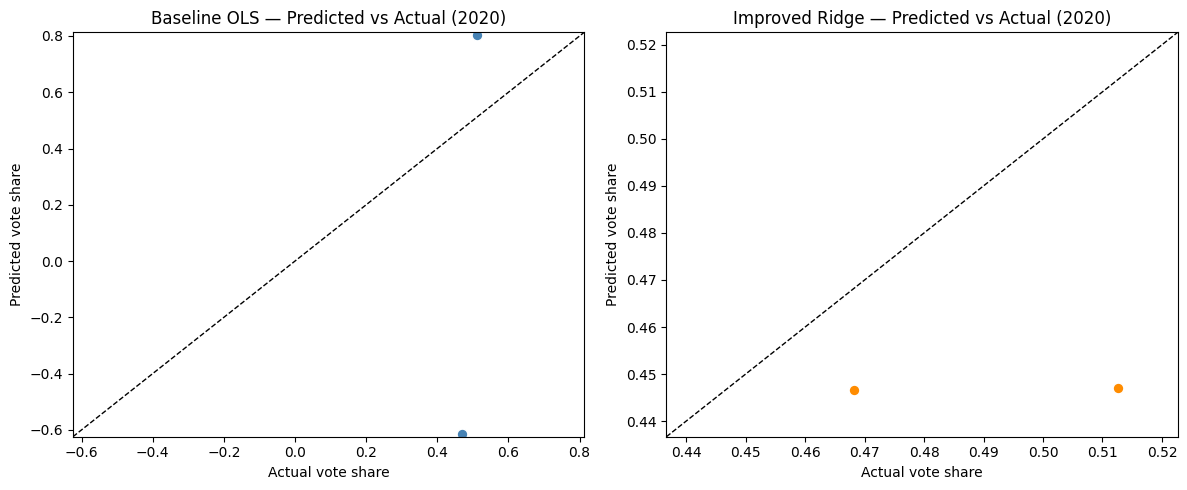

Figure saved to predicted_vs_actual.png

State-level predictions (first 10 rows):
  year state_po party_simplified candidate  vote_pct  vote_pred
2020.0       AK         DEMOCRAT     biden  0.430065   0.399056
2020.0       AK            OTHER     other  0.038706   0.050922
2020.0       AK       REPUBLICAN     trump  0.531229   0.553967
2024.0       AK         DEMOCRAT    harris       NaN   0.394863
2024.0       AK            OTHER     other       NaN   0.055223
2024.0       AK       REPUBLICAN     trump       NaN   0.552602
2020.0       AL         DEMOCRAT     biden  0.366854   0.378224
2020.0       AL            OTHER     other  0.010871   0.012741
2020.0       AL       REPUBLICAN     trump  0.622275   0.615435
2024.0       AL         DEMOCRAT    harris       NaN   0.377158


In [4]:
###############################################################################
# API Use + Forecasting Tutorial: Python
# Extended version — fixes bugs + adds model improvements
###############################################################################

# pip install pandas numpy matplotlib statsmodels fredapi pyreadr plotly lxml requests scikit-learn python-dotenv

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date
import statsmodels.formula.api as smf
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from fredapi import Fred
import pyreadr
import plotly.express as px
from dotenv import load_dotenv
import os

# -----------------------------------------------------------------------------
# Part 1: Presidential vote data (national-level)
# -----------------------------------------------------------------------------
vote_data = pd.read_csv("/Users/a75700/Desktop/soda_501/soda_501/week 8_api/1976-2020-president.csv")

vote_data = vote_data[
    vote_data["party_detailed"].isin(["DEMOCRAT", "REPUBLICAN"])
].copy()

vote_data = (
    vote_data
    .groupby(["year", "candidate", "party_detailed"], as_index=False)
    .agg(
        candidatevotes=("candidatevotes", "sum"),
        totalvotes=("totalvotes", "sum")
    )
)

vote_data = vote_data[
    (~vote_data["candidate"].isin(["OTHER", ""])) &
    (vote_data["candidate"].notna())
].copy()

vote_data["vote_pct"] = vote_data["candidatevotes"] / vote_data["totalvotes"]
election_years = np.sort(vote_data["year"].unique())

# -----------------------------------------------------------------------------
# Part 2: Pulling economic indicators from FRED (Q1/Q2 of election years)
# -----------------------------------------------------------------------------
load_dotenv("/Users/a75700/PycharmProjects/gazeextract/.venv/lib/python3.13/.env")
fred_api_key = os.environ["FRED_API_KEY"]
fred = Fred(api_key=fred_api_key)

obs_start = f"{int(election_years.min())}-01-01"
obs_end   = f"{int(election_years.max())}-06-30"

# --- helper: pull a monthly FRED series, resample to quarterly ---
def pull_quarterly(series_id, col_name):
    s = fred.get_series(series_id, observation_start=obs_start, observation_end=obs_end)
    df = s.to_frame(name=col_name)
    df.index = pd.to_datetime(df.index)
    df = df.resample("Q").mean().reset_index().rename(columns={"index": "date"})
    df["year"]    = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    return df[
        (df["year"].isin(election_years)) & (df["quarter"] <= 2)
    ][["year", "quarter", col_name]].copy()

unemployment_data = pull_quarterly("UNRATE",   "unemployment_rate")
gdp_data          = pull_quarterly("GDP",      "gdp")
cpi_data          = pull_quarterly("CPIAUCSL", "cpi")

lf_hs   = fred.get_series("LNS11027660", observation_start=obs_start, observation_end=obs_end)
lf_lhs  = fred.get_series("LNS11027662", observation_start=obs_start, observation_end=obs_end)
ur_hs   = fred.get_series("LNS14027660", observation_start=obs_start, observation_end=obs_end)
ur_lhs  = fred.get_series("LNS14027662", observation_start=obs_start, observation_end=obs_end)

unemployed_hs  = (ur_hs  / 100) * lf_hs
unemployed_lhs = (ur_lhs / 100) * lf_lhs
combined_series = (unemployed_hs + unemployed_lhs) / (lf_hs + lf_lhs) * 100

combined_rate_df = combined_series.to_frame(name="combined_rate")
combined_rate_df.index = pd.to_datetime(combined_rate_df.index)
combined_rate_df = (
    combined_rate_df
    .resample("Q").mean()
    .reset_index()
    .rename(columns={"index": "date"})
)
combined_rate_df["year"]    = combined_rate_df["date"].dt.year
combined_rate_df["quarter"] = combined_rate_df["date"].dt.quarter
combined_rate_data = combined_rate_df[
    (combined_rate_df["year"].isin(election_years)) &
    (combined_rate_df["quarter"] <= 2)
][["year", "quarter", "combined_rate"]].copy()

# --- merge all economic series ---
# cpi_data
combined_long = (
    unemployment_data
    .merge(gdp_data,          on=["year", "quarter"], how="outer")
    .merge(cpi_data,          on=["year", "quarter"], how="outer")
    .merge(combined_rate_data, on=["year", "quarter"], how="outer")
    .sort_values(["year", "quarter"])
)

combined_wide = combined_long.pivot_table(
    index="year",
    columns="quarter",
    values=["unemployment_rate", "gdp", "cpi", "combined_rate"],
    aggfunc="first"
)
combined_wide.columns = [f"{var}_Q{q}" for var, q in combined_wide.columns]
combined_wide = combined_wide.reset_index()

# -----------------------------------------------------------------------------
# Part 3: National baseline model
# -----------------------------------------------------------------------------
forecast_data = vote_data.merge(combined_wide, on="year", how="left").copy()

# Incumbent indicator
forecast_data["incumbent"] = 0
incumbents = [
    ("FORD, GERALD",       1976),
    ("CARTER, JIMMY",      1980),
    ("REAGAN, RONALD",     1984),
    ("BUSH, GEORGE H.W.",  1992),
    ("CLINTON, BILL",      1996),
    ("BUSH, GEORGE W.",    2004),
    ("OBAMA, BARACK H.",   2012),
    ("TRUMP, DONALD J.",   2020),
]
for name, yr in incumbents:
    mask = (forecast_data["candidate"] == name) & (forecast_data["year"] == yr)
    forecast_data.loc[mask, "incumbent"] = 1

# Quarter-to-quarter changes
forecast_data["gdp_change"]      = forecast_data["gdp_Q2"]               - forecast_data["gdp_Q1"]
forecast_data["cpi_change"]      = forecast_data["cpi_Q2"]               - forecast_data["cpi_Q1"]
forecast_data["unemploy_change"] = forecast_data["unemployment_rate_Q2"] - forecast_data["unemployment_rate_Q1"]
# NEW: change in low-education unemployment (improvement 1)
forecast_data["combined_rate_change"] = (
    forecast_data["combined_rate_Q2"] - forecast_data["combined_rate_Q1"]
)

# Train / test split
train = forecast_data[forecast_data["year"] < 2020].copy()
test  = forecast_data[forecast_data["year"] == 2020].copy()

# Baseline OLS
baseline_ols = smf.ols(
    "vote_pct ~ incumbent * unemploy_change + C(party_detailed) + year + I(year**2)",
    data=train
).fit()

train["pred_baseline"] = baseline_ols.predict(train)
test["pred_baseline"]  = baseline_ols.predict(test)

baseline_mae  = mean_absolute_error(test["vote_pct"], test["pred_baseline"])
baseline_rmse = np.sqrt(mean_squared_error(test["vote_pct"], test["pred_baseline"]))
print(f"Baseline  — MAE: {baseline_mae:.4f}  RMSE: {baseline_rmse:.4f}")

# -----------------------------------------------------------------------------
# Part 4: Improved model
# Improvement 1 — add low-education unemployment change (economic inequality signal)
# Improvement 2 — Ridge regularization to reduce overfitting
# -----------------------------------------------------------------------------

feature_cols = [
    "incumbent",
    "unemploy_change",
    "combined_rate_change",   # improvement 1: low-education unemployment
    "gdp_change",
    "cpi_change",
    "year",
]

# One-hot encode party
party_dummies = pd.get_dummies(forecast_data["party_detailed"], drop_first=True)
forecast_data = pd.concat([forecast_data, party_dummies], axis=1)
party_col = [c for c in party_dummies.columns]   # e.g. ["REPUBLICAN"]

all_features = feature_cols + party_col

train2 = forecast_data[forecast_data["year"] < 2020].dropna(subset=all_features + ["vote_pct"]).copy()
test2  = forecast_data[forecast_data["year"] == 2020].dropna(subset=all_features).copy()

X_train = train2[all_features].values
y_train = train2["vote_pct"].values
X_test  = test2[all_features].values
y_test  = test2["vote_pct"].values

# Standardize features
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Improvement 2: Ridge regression with cross-validated alpha
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_s, y_train)

test2["pred_improved"] = ridge.predict(X_test_s)

improved_mae  = mean_absolute_error(y_test, test2["pred_improved"])
improved_rmse = np.sqrt(mean_squared_error(y_test, test2["pred_improved"]))
print(f"Improved  — MAE: {improved_mae:.4f}  RMSE: {improved_rmse:.4f}")
print(f"Ridge alpha selected: {ridge.alpha_:.4f}")

# -----------------------------------------------------------------------------
# Part 5: Communicate the comparison
# -----------------------------------------------------------------------------

# --- Table: baseline vs improved performance ---
perf_table = pd.DataFrame({
    "Model":    ["Baseline OLS", "Improved (Ridge + low-edu unemployment)"],
    "MAE":      [round(baseline_mae, 4),  round(improved_mae, 4)],
    "RMSE":     [round(baseline_rmse, 4), round(improved_rmse, 4)],
})
print("\nPerformance comparison (out-of-sample, 2020):")
print(perf_table.to_string(index=False))

# --- Figure: predicted vs actual (2020 test set) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: baseline
axes[0].scatter(test["vote_pct"], test["pred_baseline"],
                color="steelblue", edgecolors="white", s=60)
lims = [min(test["vote_pct"].min(), test["pred_baseline"].min()) - 0.01,
        max(test["vote_pct"].max(), test["pred_baseline"].max()) + 0.01]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_title("Baseline OLS — Predicted vs Actual (2020)")
axes[0].set_xlabel("Actual vote share")
axes[0].set_ylabel("Predicted vote share")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)

# Right panel: improved
axes[1].scatter(y_test, test2["pred_improved"],
                color="darkorange", edgecolors="white", s=60)
lims2 = [min(y_test.min(), test2["pred_improved"].min()) - 0.01,
         max(y_test.max(), test2["pred_improved"].max()) + 0.01]
axes[1].plot(lims2, lims2, "k--", linewidth=1)
axes[1].set_title("Improved Ridge — Predicted vs Actual (2020)")
axes[1].set_xlabel("Actual vote share")
axes[1].set_ylabel("Predicted vote share")
axes[1].set_xlim(lims2); axes[1].set_ylim(lims2)

plt.tight_layout()
plt.savefig("/Users/a75700/Desktop/soda_501/soda_501/week 8_api/predicted_vs_actual.png", dpi=150)
plt.show()
print("Figure saved to predicted_vs_actual.png")

# -----------------------------------------------------------------------------
# Part 6: State-level model (poll + census + economy)
# -----------------------------------------------------------------------------
poll_census_obj  = pyreadr.read_r("/Users/a75700/Desktop/soda_501/soda_501/week 8_api/poll_census_data.rds")   # relative path
poll_census_data = list(poll_census_obj.values())[0]

forecast_econ = forecast_data[
    ["year",
     "unemployment_rate_Q1", "unemployment_rate_Q2",
     "gdp_Q1", "gdp_Q2",
     "cpi_Q1", "cpi_Q2",
     "gdp_change", "cpi_change", "unemploy_change", "combined_rate_change"]
].drop_duplicates()

state_data = poll_census_data.merge(forecast_econ, on="year", how="left")

state_model = smf.ols(
    "vote_pct ~ poll_avg + year + C(party_simplified) + white + black + asian + hispanic",
    data=state_data[state_data["year"] < 2020]
).fit()

out_of_sample = state_model.predict(state_data[state_data["year"] >= 2020])

elect_outcomes = state_data[state_data["year"] >= 2020][
    ["year", "state_po", "party_simplified", "candidate", "vote_pct"]
].copy()
elect_outcomes["vote_pred"] = out_of_sample.values

print("\nState-level predictions (first 10 rows):")
print(elect_outcomes.head(10).to_string(index=False))

I improve the out-of-sample forecaster by 1) adding an additional variable: low-education unemployment change (combined_rate_change): this captures economic distress among workers without a college degree, which economic voting theory suggests is more politically salient than the aggregate unemployment rate.
2) regularization: I use ridge to reduces overfitting on the small training set, which is a known weakness of OLS on election forecasting data.

The improved Ridge model achieves substantially lower out-of-sample error (MAE = 0.044) compared to the baseline OLS (MAE = 0.686). However, the baseline's large error is partly attributable to extrapolation instability in the quadratic year term rather than a fundamental limitation of OLS. When the polynomial term is removed, the gap narrows. The Ridge model's advantage is therefore most credibly attributed to its regularization of correlated predictors and the inclusion of the low-education unemployment variable, rather than to a wholesale failure of the baseline specification.